## Calculate Foote Novelty

This script calculates foote novelty transitions inspired by "Professional Jazz Musicians Explore and Exploit a Space of Sounds" (Williams et al., 2024) to explore changes in topic within conversation transcripts. 

**Author:** Helen Schmidt  
**Python version:** 3.11.14

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap, Normalize


In [3]:
# define data input location
input_dir = "/Users/helenschmidt/Library/CloudStorage/GoogleDrive-helenschmidt129@gmail.com/My Drive/SANLab/Experiments/Conversation-Structure/data/output/full-sample"
# define data output location
output_dir = input_dir

In [4]:
# define function to calculate turn angle
# calculate the cosine similarity of the turn angles, rather than adjacent turns
def compute_turn_angles_adjacent_windows(df):
    results = []

    # group by transcript
    for transcript_id, group in df.groupby('transcript_id'):
        if len(group) < 2:
            continue  # need at least 2 windows to compute a turn
        
        # stack embeddings
        A = np.vstack([emb.squeeze() for emb in group['A_embeddings'].values[:-1]])
        B = np.vstack([emb.squeeze() for emb in group['B_embeddings'].values[:-1]])
        C = np.vstack([emb.squeeze() for emb in group['B_embeddings'].values[1:]])
        
        # vectors from B
        BA = A - B
        BC = C - B
        
        # cosine turn angle
        cos_theta = np.array([
            cosine_similarity(BA[i].reshape(1,-1), BC[i].reshape(1,-1))[0,0]
            for i in range(len(BA))
        ])
        
        # aligned raw turn/time
        a_times = group['A_start_turn'].values[:-1] #A_start_time for time, A_start_turn for turn

        # save results
        res_df = pd.DataFrame({
            'transcript_id': transcript_id,
            'turn_index': np.arange(len(cos_theta)),
            'A_start_turn': a_times, #A_start_time for time, A_start_turn for turn
            'cosine_turn': cos_theta,
            'turn_embedding': [emb.squeeze() for emb in group['B_embeddings'].values[:-1]], # angle centered at B
            'BA_vector': [vec for vec in BA], # vector A > B
            'BC_vector': [vec for vec in BC]  # vector B > C
        })
        
        results.append(res_df)
    
    return pd.concat(results, ignore_index=True)

In [5]:
test = pd.read_pickle(input_dir + '/full_sample_tile_4_turn_split_sentences_by_speaker.pkl')
test.head()

,transcript_id,speaker_mode,mode,window_size,gap_size,A_speaker,B_speaker,A_start_turn,A_end_turn,B_start_turn,B_end_turn,A_utterances,B_utterances,A_embeddings,B_embeddings,cosine_similarity,euclidean_distance
0,0020a0c5-1658-4747-99c1-2839e736b481,by_speaker,turn,4,0,5a73899f9cdd1800017786f0,5fa072f4f4aa580b63834357,1,4,1,4,hey I'm gone. yeah I've done a few of these be...,"good, how are you? Yeah. Yeah, so this will be...","[-0.05925276, -0.038165268, 0.042457737, 0.037...","[-0.005335846, -0.054031678, 0.025666948, 0.03...",0.472280,0.641885
1,0020a0c5-1658-4747-99c1-2839e736b481,by_speaker,turn,4,0,5fa072f4f4aa580b63834357,5a73899f9cdd1800017786f0,1,4,5,8,"good, how are you? Yeah. Yeah, so this will be...",not too bad. Feel a little crappy today but hu...,"[-0.005335846, -0.054031678, 0.025666948, 0.03...","[-0.06539267, -0.016892936, 0.035326734, 0.000...",0.383021,0.718863
2,0020a0c5-1658-4747-99c1-2839e736b481,by_speaker,turn,4,0,5a73899f9cdd1800017786f0,5fa072f4f4aa580b63834357,5,8,5,8,not too bad. Feel a little crappy today but hu...,"I don't know. no, are you getting sick? Oh tha...","[-0.06539267, -0.016892936, 0.035326734, 0.000...","[0.012232751, -0.02369256, 0.021855786, 0.0089...",0.451708,0.668791
3,0020a0c5-1658-4747-99c1-2839e736b481,by_speaker,turn,4,0,5fa072f4f4aa580b63834357,5a73899f9cdd1800017786f0,5,8,9,12,"I don't know. no, are you getting sick? Oh tha...",22 girls if I'm enjoy it while you can they've...,"[0.012232751, -0.02369256, 0.021855786, 0.0089...","[0.010743233, -0.03177115, -0.0020472077, 0.03...",0.317040,0.707071
4,0020a0c5-1658-4747-99c1-2839e736b481,by_speaker,turn,4,0,5a73899f9cdd1800017786f0,5fa072f4f4aa580b63834357,9,12,9,12,22 girls if I'm enjoy it while you can they've...,that's awesome. So I have no kids myself not a...,"[0.010743233, -0.03177115, -0.0020472077, 0.03...","[-0.017096415, -0.017585017, -0.0006486433, 0....",0.542900,0.587993


## Testing Combinations of Kernel Sizes and Foote Novelty Thresholds

In [6]:
# create a list of the data files
files = [
    '/full_sample_tile_4_turn_split_sentences.pkl',
    '/full_sample_tile_4_turn_split_utterances.pkl',
    '/full_sample_tile_4_turn_split_sentences_by_speaker.pkl',
    '/full_sample_tile_4_turn_split_utterances_by_speaker.pkl']

# create containers for all results
foote_results = {}

kernel_sizes = [6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
foote_thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.75, 1, 1.25, 1.5]

# loop through thresholds
for t in foote_thresholds:
    # loop through kernel sizes
    for s in kernel_sizes:
        # loop through files
        for f in files:

            # read in data file
            df = pd.read_pickle(input_dir + f)

            all_results = []
            type_col = 'A_start_turn'

            for transcript_id, group in df.groupby('transcript_id'):
                group = group.sort_values(type_col).reset_index(drop=True)

                # build embedding trajectory
                embeddings_list = [emb.squeeze() for emb in group['A_embeddings'].values]
                embeddings_list.append(group['B_embeddings'].values[-1].squeeze())
                embeddings = np.vstack(embeddings_list)
                n = embeddings.shape[0]

                if n < 4:
                    continue

                # build time list
                time_list = list(group[type_col].values)
                time_list.append(time_list[-1])

                # speaker-based?
                speaker_based = 'by_speaker' in f
                if speaker_based and 'speaker' in group.columns:
                    speaker_list = list(group['speaker'].values)
                    speaker_list.append(speaker_list[-1])
                else:
                    speaker_list = [None] * n

                # compute self-similarity matrix (how similar is each embedding to all other embeddings in the convo?)
                # https://ccrma.stanford.edu/workshops/mir2009/references/Foote_00.pdf 
                # cosine similarity matrix
                S = cosine_similarity(embeddings)

                # ---- foote novelty ---- #
                k = s // 2 # bigger values = detect larger shifts
                kernel = np.block([
                    [np.ones((k, k)), -np.ones((k, k))],
                    [-np.ones((k, k)), np.ones((k, k))]
                ])
                kernel = kernel / np.sqrt((s ** 2) / 2)

                novelty = np.zeros(n)
                for i in range(k, n - k):
                    sub = S[i - k:i + k, i - k:i + k]
                    novelty[i] = np.sum(sub * kernel)

                # normalize 0-1
                novelty = (novelty - novelty.min()) / (novelty.max() - novelty.min() + 1e-8)

                # get utterances
                utterances_list = list(group['A_utterances'].values)       # all A utterances
                utterances_list.append(group['B_utterances'].values[-1])   # append last B utterance

                # save transcript results
                temp = pd.DataFrame({
                    'transcript_id': transcript_id,
                    'time_index': np.arange(n),
                    'A_start_turn': time_list,
                    'foote_novelty': novelty,
                    'speaker': speaker_list,
                    'utterance': utterances_list
                })
                all_results.append(temp)

            # combine transcripts
            foote_df = pd.concat(all_results, ignore_index=True)

            # mark predicted shifts when foote novelty is X SD away from overall transcript mean foote novelty
            foote_df['predicted_shift'] = 0
            for tid, group in foote_df.groupby('transcript_id'):
                mean_nov = group['foote_novelty'].mean()
                std_nov = group['foote_novelty'].std()
                threshold = mean_nov + t * std_nov

                idx = group.index[group['foote_novelty'] > threshold]
                foote_df.loc[idx, 'predicted_shift'] = 1
                foote_df.loc[group.index, 'threshold'] = threshold

            # save out data
            data_name = f.replace(".pkl", "").replace("/", "")
            foote_results_key = f"{t}_foote_{s}_kernel_{data_name}"
            foote_results[foote_results_key] = foote_df

            foote_df.to_csv(f"{output_dir}/{foote_results_key}.csv", index=False)
            foote_df.to_pickle(f"{output_dir}/{foote_results_key}.pkl")

## Test Best Fit

Loading the participant data we have, find the best fitting combination of kernel size and foote novelty threshold. Our goal is to align the data-driven approach with the human annotators, so picking the best fit is not only really important on its own, but it's also really important we robustly test these combinations and get a measure of fit.

In other words, **how well does the data-driven approach to identifying topic shifts align with human annotated topic shifts, and vice versa?**

In [7]:
# load full sample annotation data
ann_df = pd.read_csv('/Users/helenschmidt/Library/CloudStorage/GoogleDrive-helenschmidt129@gmail.com/My Drive/SANLab/Experiments/Conversation-Structure/data/processed/full-sample/full_sample_processed.csv')
ann_df.head()

,turn_id,speaker,currentUtterance,previous_topic,new_topic,PID,time,transcript_id,count
0,13,5c270d8f2c45d400014909e8,just got done trying to figure out what to do ...,Test Topic,What is for dinner,"[False, '6100b9bc3ca21392600e905c', None]",1.745012e+12,339012e4-ada1-4c88-839d-08a6842b5903,205.0
1,36,5c270d8f2c45d400014909e8,Yeah. What part of new york?,What is for dinner,Living arrangements,"[False, '6100b9bc3ca21392600e905c', None]",1.745012e+12,339012e4-ada1-4c88-839d-08a6842b5903,205.0
2,51,5c270d8f2c45d400014909e8,"how is it right now, as far as like environmen...",Living arrangements,Politics,"[False, '6100b9bc3ca21392600e905c', None]",1.745012e+12,339012e4-ada1-4c88-839d-08a6842b5903,205.0
3,63,5c270d8f2c45d400014909e8,"Well, we were doing pretty good and lately the...",Politics,Different politics,"[False, '6100b9bc3ca21392600e905c', None]",1.745012e+12,339012e4-ada1-4c88-839d-08a6842b5903,205.0
4,78,5eece89d63352e0c327ddb0b,"it was mostly really, it was seriously overblo...",Different politics,New politics,"[False, '6100b9bc3ca21392600e905c', None]",1.745012e+12,339012e4-ada1-4c88-839d-08a6842b5903,205.0


In [8]:
# print the number of transcripts in full sample
ann_df['transcript_id'].nunique()

1464

In [9]:
# get dense sample annotation data
dense_df = pd.read_csv('/Users/helenschmidt/Library/CloudStorage/GoogleDrive-helenschmidt129@gmail.com/My Drive/SANLab/Experiments/Conversation-Structure/data/processed/dense_subset_processed.csv')
dense_df.head()

,transcript_id,turn_id,scaled_turn_id,PID,utterance,currentUtterance,previous_topic,new_topic
0,01849238-f5f0-487e-bca4-7b4fe0c9625c,0,0.00,NaN,mm. Mhm. Okay. Okay. Mm hmm. Mhm. Oh. Mhm. Oka...,NaN,NaN,NaN
1,01849238-f5f0-487e-bca4-7b4fe0c9625c,1,0.00,"[False, '66ea5116a642813c3dcf3c6f', None]","Hello, Can you hear me? I can, how are you doing?","Hello, Can you hear me? I can, how are you doing?",Starting The Call,Greeting
2,01849238-f5f0-487e-bca4-7b4fe0c9625c,2,0.01,NaN,Good. How about you?,NaN,NaN,NaN
3,01849238-f5f0-487e-bca4-7b4fe0c9625c,3,0.01,NaN,"I am doing well, yeah,",NaN,NaN,NaN
4,01849238-f5f0-487e-bca4-7b4fe0c9625c,4,0.01,"[False, '66ea5116a642813c3dcf3c6f', None]",Sweet. So um I guess we could start off by tal...,Sweet. So um I guess we could start off by tal...,Greeting,Introductions


In [10]:
# print the number of transcripts in dense sample
dense_df['transcript_id'].nunique()

200

In [11]:
# combine dense and full samples
cols_to_keep = ['transcript_id', 'PID', 'previous_topic', 'new_topic', 'currentUtterance', 'turn_id']

# subset each dataframe
ann_subset = ann_df[cols_to_keep]
dense_subset = dense_df[cols_to_keep]

# row bind (concatenate)
merged_ann_df = pd.concat([ann_subset, dense_subset], ignore_index=True)

# check result
merged_ann_df.head()

,transcript_id,PID,previous_topic,new_topic,currentUtterance,turn_id
0,339012e4-ada1-4c88-839d-08a6842b5903,"[False, '6100b9bc3ca21392600e905c', None]",Test Topic,What is for dinner,just got done trying to figure out what to do ...,13
1,339012e4-ada1-4c88-839d-08a6842b5903,"[False, '6100b9bc3ca21392600e905c', None]",What is for dinner,Living arrangements,Yeah. What part of new york?,36
2,339012e4-ada1-4c88-839d-08a6842b5903,"[False, '6100b9bc3ca21392600e905c', None]",Living arrangements,Politics,"how is it right now, as far as like environmen...",51
3,339012e4-ada1-4c88-839d-08a6842b5903,"[False, '6100b9bc3ca21392600e905c', None]",Politics,Different politics,"Well, we were doing pretty good and lately the...",63
4,339012e4-ada1-4c88-839d-08a6842b5903,"[False, '6100b9bc3ca21392600e905c', None]",Different politics,New politics,"it was mostly really, it was seriously overblo...",78


In [12]:
# how many transcripts in the combined annotation data?
merged_ann_df['transcript_id'].nunique()

1652

Great, there are 1656 total transcripts, and we know that we're excluding one, with a total N of 1655. That means we're only missing 3 annotated transcripts, plus any more that need to be collected again due to poor data quality. We'll figure that out soon...

### Formatting Participant Data

In [ ]:
# normalize the utterances from foote_results and combined annotations
def normalize_text(s):
    return " ".join(str(s).lower().strip().split())

merged_ann_df["utter_norm"] = merged_ann_df["currentUtterance"].apply(normalize_text)

# count how many PIDs marked a given utterance as a shift within each transcript
pid_counts = (merged_ann_df.groupby(['transcript_id', 'utter_norm'])
              .PID.nunique()
              .reset_index(name='participant_shifts'))
# preview
pid_counts.head()

,transcript_id,utter_norm,participant_shifts
0,0020a0c5-1658-4747-99c1-2839e736b481,are there any insider secrets you can tell me ...,1
1,0020a0c5-1658-4747-99c1-2839e736b481,"do you guys do stuff, did you guys do stuff fo...",1
2,0020a0c5-1658-4747-99c1-2839e736b481,"i work at an old factory,",1
3,0020a0c5-1658-4747-99c1-2839e736b481,like talking all the things i want to do as so...,1
4,0020a0c5-1658-4747-99c1-2839e736b481,"my god, i'm let's see myself personally, i don...",1


### Hit Rate & FA Rate

In [14]:
# get hit rate and false alarm rate for all combinations of kernel sizes and foote novely thresholds
# only do main data type for now

# save results
rate_results = []

# loop through foote_results
for key, df in foote_results.items():
    # only main data type
    if "full_sample_tile_4_turn_split_sentences" not in key: continue

    # extract foote threshold and kernel size from key
    parts = key.split("_")
    foote_threshold = float(parts[0])
    kernel_size = int(parts[2])

    # normalize utterances 
    df["utter_norm"] = df["utterance"].apply(normalize_text)

    # combine with participant_counts
    combined_df = df.merge(
        pid_counts,
        on = ['transcript_id', 'utter_norm'],
        how = "left"
    )

    # fill NAs and make binary
    combined_df["participant_shifts"] = combined_df["participant_shifts"].fillna(0)
    combined_df["participant_shifts"] = (combined_df["participant_shifts"] > 0).astype(int)

    # get predictions
    y_pid = combined_df["participant_shifts"].astype(int)
    y_pred = combined_df["predicted_shift"].astype(int)

    # compute TP, FN, FP, TN
    TP = np.sum((y_pid == 1) & (y_pred == 1))
    FN = np.sum((y_pid == 1) & (y_pred == 0))
    FP = np.sum((y_pid == 0) & (y_pred == 1))
    TN = np.sum((y_pid == 0) & (y_pred == 0))

    # hit rate and false alarm rate
    hit_rate = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    fa_rate = FP / (FP + TN) if (FP + TN) > 0 else np.nan

    # save results
    rate_results.append({
        'foote_threshold': foote_threshold,
        'kernel_size': kernel_size,
        'hit_rate': hit_rate,
        'false_alarm_rate': fa_rate
    })

# combine into data frame
results_df = pd.DataFrame(rate_results)

# sort
results_df = results_df.sort_values('hit_rate', ascending=False)
print(results_df)


KeyboardInterrupt: 

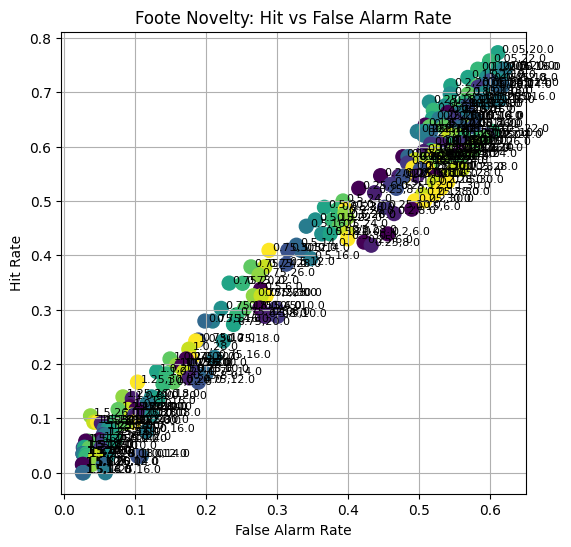

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(results_df['false_alarm_rate'], results_df['hit_rate'], c=results_df['kernel_size'], cmap='viridis', s=100)
for i, row in results_df.iterrows():
    plt.text(row['false_alarm_rate']+0.005, row['hit_rate'], f"{row['foote_threshold']},{row['kernel_size']}", fontsize=8)

plt.xlabel("False Alarm Rate")
plt.ylabel("Hit Rate")
plt.title("Foote Novelty: Hit vs False Alarm Rate")
plt.grid(True)
plt.show()

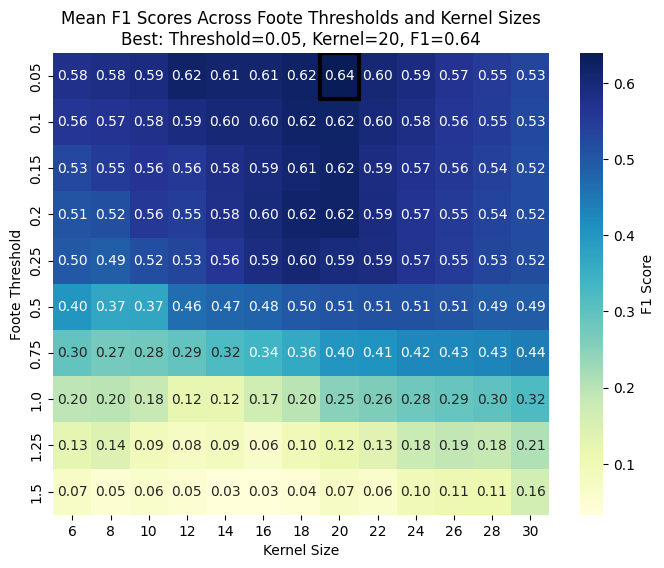

In [ ]:
# calculate f1 scores
results_df['precision'] = results_df['hit_rate'] / (results_df['hit_rate'] + results_df['false_alarm_rate'] + 1e-8)
results_df['f1_score'] = 2 * (results_df['hit_rate'] * results_df['precision']) / (results_df['hit_rate'] + results_df['precision'] + 1e-8)

# aggregate mean F1 for each threshold/kernel combination
f1_agg = results_df.groupby(['foote_threshold', 'kernel_size'])['f1_score'].mean().reset_index()

# pivot for heatmap
f1_matrix = f1_agg.pivot(index='foote_threshold', columns='kernel_size', values='f1_score')

# find best combination
best_idx = np.unravel_index(f1_matrix.values.argmax(), f1_matrix.shape)
best_threshold = f1_matrix.index[best_idx[0]]
best_kernel = f1_matrix.columns[best_idx[1]]
best_f1 = f1_matrix.values[best_idx]

# plot heatmap
plt.figure(figsize=(8,6))
ax = sns.heatmap(f1_matrix, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label':'F1 Score'})

# highlight best cell with black rectangle
ax.add_patch(plt.Rectangle(
    (best_idx[1], best_idx[0]), 1, 1, fill=False, edgecolor='black', lw=3
))

plt.title("Mean F1 Scores Across Foote Thresholds and Kernel Sizes\nBest: Threshold={}, Kernel={}, F1={:.2f}".format(best_threshold, best_kernel, best_f1))
plt.xlabel("Kernel Size")
plt.ylabel("Foote Threshold")
plt.show()

In [ ]:
# save best fitting data
#best_data = foote_results['0.05_foote_20_kernel_full_sample_tile_4_turn_split_sentences']
best_data = foote_results['0.2_foote_20_kernel_full_sample_tile_4_turn_split_sentences']

best_data.to_csv(f"{output_dir}/best_foote_0.2_threshold_20_kernel.csv", index=False)
best_data.to_pickle(f"{output_dir}/best_foote_0.2_threshold_20_kernel.pkl")

# preview
best_data.head()

NameError: name 'foote_results' is not defined

# ---------------- ARCHIVE ---------------------
## Load Data

We have four data sets - the primary splits long utterances at the sentence level and looks at the speaker level.

The other data sets split long utterances at the word level and speaker level, at the word level and regardless of speaker, and at the word level and at the speaker level.

In [ ]:
# create a list of the data files
files = ['/full_sample_tile_4_turn_split_sentences.pkl', '/full_sample_tile_4_turn_split_utterances.pkl', '/full_sample_tile_4_turn_split_sentences_by_speaker.pkl', '/full_sample_tile_4_turn_split_utterances_by_speaker.pkl']

# create containers for all results
foote_results = {}
turn_angle_results = {}

# loop through files and calculate foote novelty
for f in files:

    # read in the data file
    df = pd.read_pickle(input_dir + f)

    # get turn angle cosine similarity
    df_turn_angle = compute_turn_angles_adjacent_windows(df)

    # calculate foote novelty
    all_results = []
    type = 'A_start_turn'

    for transcript_id, group in df.groupby('transcript_id'):
        # sort by conversation within each transcript
        group = group.sort_values(type).reset_index(drop=True)
        
        # construct a full embedding trajectory (starting with first A_embeddings and ending with last B_embeddings)
        embeddings_list = [emb.squeeze() for emb in group['A_embeddings'].values]
        embeddings_list.append(group['B_embeddings'].values[-1].squeeze())
        embeddings = np.vstack(embeddings_list)

        n = embeddings.shape[0]
        if n < 4: continue

        # build time list (one per A, then repeat the last A time for final B)
        time_list = list(group[type].values)
        time_list.append(time_list[-1]) # align with B_embeddings row

        # determine if this is speaker-based or overall
        speaker_based = 'by_speaker' in f

        # build speaker list if speaker-based
        if speaker_based and 'speaker' in group.columns:
            speaker_list = list(group['speaker'].values)
            speaker_list.append(speaker_list[-1])
        else:
            speaker_list = [None] * n  # placeholder if no speaker

        # compute self-similarity matrix (how similar is each embedding to all other embeddings in the convo?)
        # https://ccrma.stanford.edu/workshops/mir2009/references/Foote_00.pdf 
        S = cosine_similarity(embeddings)

        # build the checkerboard kernel
        kernel_size = 10 # bigger values = detect larger shifts
        k = kernel_size // 2
        kernel = np.block([
            [np.ones((k, k)), -np.ones((k, k))],
            [-np.ones((k, k)), np.ones((k, k))]
        ])
        kernel = kernel / np.sqrt((kernel_size ** 2) / 2)

        # compute foote novelty
        novelty = np.zeros(n)
        for i in range(k, n - k):
            sub = S[i - k:i + k, i - k:i + k]
            novelty[i] = np.sum(sub * kernel)

        # normalize the novelty scores from 0 to 1
        novelty = (novelty - novelty.min()) / (novelty.max() - novelty.min() + 1e-8)

        # save results for this transcript
        temp = pd.DataFrame({
            'transcript_id': transcript_id,
            'time_index': np.arange(n),   # each embedding position
            'A_start_turn': time_list,    # save raw info
            'foote_novelty': novelty,
            'speaker': speaker_list
        })
        all_results.append(temp)

    # combine all transcripts
    foote_df = pd.concat(all_results, ignore_index=True)

    # mark predicted shifts when foote novelty is X SD away from overall transcript mean foote novelty
    foote_df['predicted_shift'] = 0

    for tid, group in foote_df.groupby('transcript_id'):
        mean_nov = group['foote_novelty'].mean()
        std_nov  = group['foote_novelty'].std()
        threshold = mean_nov + 0.5 * std_nov #1.5x, 0.75x
    
        # mark points above threshold
        idx = group.index[group['foote_novelty'] > threshold]
        foote_df.loc[idx, 'predicted_shift'] = 1

        # save threshold
        foote_df.loc[group.index, 'threshold'] = threshold

    # ---- save ----- #
    
    # get data name from filename
    data_name = f.replace(".pkl", "").replace("/", "")

    # store in dictionary created at the beginning
    foote_results[data_name] = foote_df

    # store turn angle results too
    turn_angle_results[data_name] = df_turn_angle

    # save
    foote_df.to_csv(f"{output_dir}/foote_{data_name}.csv", index=False)
    foote_df.to_pickle(f"{output_dir}/foote_{data_name}.pkl")


In [ ]:
## calculate alternative levels of foote novelty thresholds (0.75, 1, 1.25, 1.5)
## also do a range of kernel sizes

# create a list of the data files
files = ['/full_sample_tile_4_turn_split_sentences.pkl', '/full_sample_tile_4_turn_split_utterances.pkl', '/full_sample_tile_4_turn_split_sentences_by_speaker.pkl', '/full_sample_tile_4_turn_split_utterances_by_speaker.pkl']

# create containers for all results
foote_results = {}

kernel_sizes = [6, 10, 16, 24]
foote_thresholds = [0.25, 0.75, 1, 1.25, 1.5]

# loop through alternative levels of foote novelty thresholds
for t in foote_thresholds:
    # loop through files and calculate foote novelty
    for f in files:

        # read in data file
        df = pd.read_pickle(input_dir + f)

        # calculate foote novelty
        all_results = []
        type = 'A_start_turn'
        for transcript_id, group in df.groupby('transcript_id'):
            # sort by conversation within each transcript
            group = group.sort_values(type).reset_index(drop=True)
            # construct a full embedding trajectory (starting with first A_embeddings and ending with last B_embeddings)
            embeddings_list = [emb.squeeze() for emb in group['A_embeddings'].values]
            embeddings_list.append(group['B_embeddings'].values[-1].squeeze())
            embeddings = np.vstack(embeddings_list)
            n = embeddings.shape[0]

            if n < 4: continue
            # build time list (one per A, then repeat the last A time for final B)
            time_list = list(group[type].values)
            time_list.append(time_list[-1]) # align with B_embeddings row
            # determine if this is speaker-based or overall
            speaker_based = 'by_speaker' in f
            # build speaker list if speaker-based
            if speaker_based and 'speaker' in group.columns:
                speaker_list = list(group['speaker'].values)
                speaker_list.append(speaker_list[-1])
            else:
                speaker_list = [None] * n  # placeholder if no speaker

            # compute self-similarity matrix (how similar is each embedding to all other embeddings in the convo?)
            # https://ccrma.stanford.edu/workshops/mir2009/references/Foote_00.pdf 
            S = cosine_similarity(embeddings)

            # build the checkerboard kernel
            kernel_size = s # bigger values = detect larger shifts
            k = kernel_size // 2
            kernel = np.block([
                [np.ones((k, k)), -np.ones((k, k))],
                [-np.ones((k, k)), np.ones((k, k))]
            ])
            kernel = kernel / np.sqrt((kernel_size ** 2) / 2)

            # compute foote novelty
            novelty = np.zeros(n)
            for i in range(k, n - k):
                sub = S[i - k:i + k, i - k:i + k]
                novelty[i] = np.sum(sub * kernel)

            # normalize the novelty scores from 0 to 1
            novelty = (novelty - novelty.min()) / (novelty.max() - novelty.min() + 1e-8)

            # save results for this transcript
            temp = pd.DataFrame({
                'transcript_id': transcript_id,
                'time_index': np.arange(n),   # each embedding position
                'A_start_turn': time_list,    # save raw info
                'foote_novelty': novelty,
                'speaker': speaker_list
            })
            all_results.append(temp)

        # combine all transcripts
        foote_df = pd.concat(all_results, ignore_index=True)

        # mark predicted shifts when foote novelty is X SD away from overall transcript mean foote novelty
        foote_df['predicted_shift'] = 0

        for tid, group in foote_df.groupby('transcript_id'):
            mean_nov = group['foote_novelty'].mean()
            std_nov  = group['foote_novelty'].std()
            threshold = mean_nov + t * std_nov # iterate through each threshold
    
            # mark points above threshold
            idx = group.index[group['foote_novelty'] > threshold]
            foote_df.loc[idx, 'predicted_shift'] = 1

            # save threshold
            foote_df.loc[group.index, 'threshold'] = threshold

        # ---- save ----- #
    
        # get data name from filename
        data_name = f.replace(".pkl", "").replace("/", "")

        # store in dictionary created at the beginning
        foote_results[data_name] = foote_df

        # save
        foote_df.to_csv(f"{output_dir}/{t}_foote_{data_name}.csv", index=False)
        foote_df.to_pickle(f"{output_dir}/{t}_foote_{data_name}.pkl")




## Data Previews + Plots

In [50]:
# plot example conversation's peaks of cosine similarities
transcript_id = '0020a0c5-1658-4747-99c1-2839e736b481'

0.6672425497830365


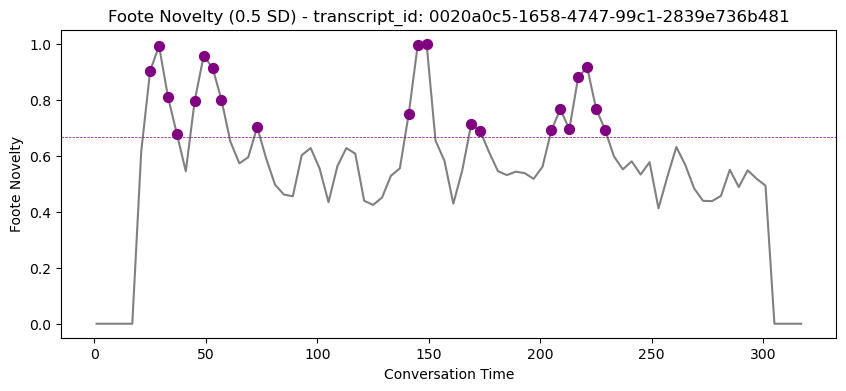

                           transcript_id  time_index  A_start_turn  \
6   0020a0c5-1658-4747-99c1-2839e736b481           6            25   
7   0020a0c5-1658-4747-99c1-2839e736b481           7            29   
8   0020a0c5-1658-4747-99c1-2839e736b481           8            33   
9   0020a0c5-1658-4747-99c1-2839e736b481           9            37   
11  0020a0c5-1658-4747-99c1-2839e736b481          11            45   
12  0020a0c5-1658-4747-99c1-2839e736b481          12            49   
13  0020a0c5-1658-4747-99c1-2839e736b481          13            53   
14  0020a0c5-1658-4747-99c1-2839e736b481          14            57   
18  0020a0c5-1658-4747-99c1-2839e736b481          18            73   
35  0020a0c5-1658-4747-99c1-2839e736b481          35           141   
36  0020a0c5-1658-4747-99c1-2839e736b481          36           145   
37  0020a0c5-1658-4747-99c1-2839e736b481          37           149   
42  0020a0c5-1658-4747-99c1-2839e736b481          42           169   
43  0020a0c5-1658-47

In [51]:
# subset to one type of data
this_data = foote_results["full_sample_tile_4_turn_split_sentences"]
subset = this_data[this_data['transcript_id'] == transcript_id].reset_index(drop=True)
predicted_shift_points = subset[subset['predicted_shift'] == 1]

threshold_val = subset['threshold'].iloc[0]   # get threshold value for this transcript
print(threshold_val) # print threshold

plt.figure(figsize=(10, 4))
sns.lineplot(data=subset, x='A_start_turn', y='foote_novelty', color = 'grey')
plt.scatter(predicted_shift_points['A_start_turn'], predicted_shift_points['foote_novelty'], color = 'purple', s = 50, zorder = 3)
plt.axhline(y=threshold_val, linestyle='--', linewidth=0.5, color='purple')
plt.title(f'Foote Novelty (0.5 SD) - transcript_id: {transcript_id}')
plt.xlabel('Conversation Time')
plt.ylabel('Foote Novelty')
plt.show()

## print predicted shifts
print(subset[subset['predicted_shift'] == 1])

0.6397162401377241


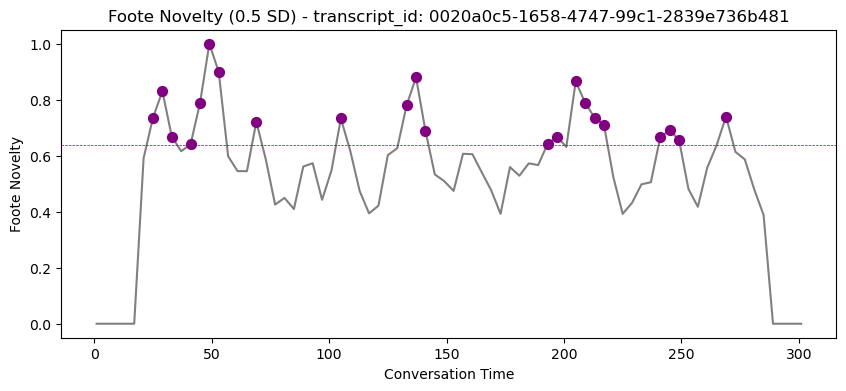

                           transcript_id  time_index  A_start_turn  \
6   0020a0c5-1658-4747-99c1-2839e736b481           6            25   
7   0020a0c5-1658-4747-99c1-2839e736b481           7            29   
8   0020a0c5-1658-4747-99c1-2839e736b481           8            33   
10  0020a0c5-1658-4747-99c1-2839e736b481          10            41   
11  0020a0c5-1658-4747-99c1-2839e736b481          11            45   
12  0020a0c5-1658-4747-99c1-2839e736b481          12            49   
13  0020a0c5-1658-4747-99c1-2839e736b481          13            53   
17  0020a0c5-1658-4747-99c1-2839e736b481          17            69   
26  0020a0c5-1658-4747-99c1-2839e736b481          26           105   
33  0020a0c5-1658-4747-99c1-2839e736b481          33           133   
34  0020a0c5-1658-4747-99c1-2839e736b481          34           137   
35  0020a0c5-1658-4747-99c1-2839e736b481          35           141   
48  0020a0c5-1658-4747-99c1-2839e736b481          48           193   
49  0020a0c5-1658-47

In [52]:
# subset to one type of data
this_data = foote_results["full_sample_tile_4_turn_split_utterances"]
subset = this_data[this_data['transcript_id'] == transcript_id].reset_index(drop=True)
predicted_shift_points = subset[subset['predicted_shift'] == 1]

threshold_val = subset['threshold'].iloc[0]   # get threshold value for this transcript
print(threshold_val) # print threshold

plt.figure(figsize=(10, 4))
sns.lineplot(data=subset, x='A_start_turn', y='foote_novelty', color = 'grey')
plt.scatter(predicted_shift_points['A_start_turn'], predicted_shift_points['foote_novelty'], color = 'purple', s = 50, zorder = 3)
plt.axhline(y=threshold_val, linestyle='--', linewidth=0.5, color='purple')
plt.title(f'Foote Novelty (0.5 SD) - transcript_id: {transcript_id}')
plt.xlabel('Conversation Time')
plt.ylabel('Foote Novelty')
plt.show()

## print predicted shifts
print(subset[subset['predicted_shift'] == 1])

0.6711303626954012


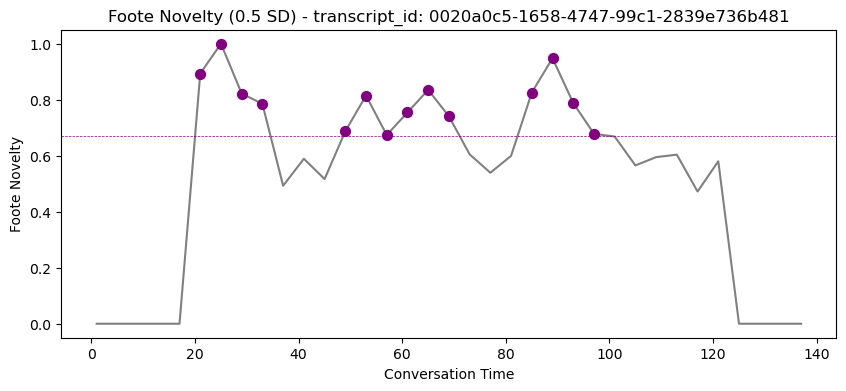

                           transcript_id  time_index  A_start_turn  \
5   0020a0c5-1658-4747-99c1-2839e736b481           5            21   
6   0020a0c5-1658-4747-99c1-2839e736b481           6            25   
7   0020a0c5-1658-4747-99c1-2839e736b481           7            29   
8   0020a0c5-1658-4747-99c1-2839e736b481           8            33   
12  0020a0c5-1658-4747-99c1-2839e736b481          12            49   
13  0020a0c5-1658-4747-99c1-2839e736b481          13            53   
14  0020a0c5-1658-4747-99c1-2839e736b481          14            57   
15  0020a0c5-1658-4747-99c1-2839e736b481          15            61   
16  0020a0c5-1658-4747-99c1-2839e736b481          16            65   
17  0020a0c5-1658-4747-99c1-2839e736b481          17            69   
21  0020a0c5-1658-4747-99c1-2839e736b481          21            85   
22  0020a0c5-1658-4747-99c1-2839e736b481          22            89   
23  0020a0c5-1658-4747-99c1-2839e736b481          23            93   
24  0020a0c5-1658-47

In [53]:
# subset to one type of data
this_data = foote_results["full_sample_tile_4_turn_split_sentences_by_speaker"]
subset = this_data[this_data['transcript_id'] == transcript_id].reset_index(drop=True)
predicted_shift_points = subset[subset['predicted_shift'] == 1]

threshold_val = subset['threshold'].iloc[0]   # get threshold value for this transcript
print(threshold_val) # print threshold

plt.figure(figsize=(10, 4))
sns.lineplot(data=subset, x='A_start_turn', y='foote_novelty', color = 'grey')
plt.scatter(predicted_shift_points['A_start_turn'], predicted_shift_points['foote_novelty'], color = 'purple', s = 50, zorder = 3)
plt.axhline(y=threshold_val, linestyle='--', linewidth=0.5, color='purple')
plt.title(f'Foote Novelty (0.5 SD) - transcript_id: {transcript_id}')
plt.xlabel('Conversation Time')
plt.ylabel('Foote Novelty')
plt.show()

## print predicted shifts
print(subset[subset['predicted_shift'] == 1])

0.6761744435172425


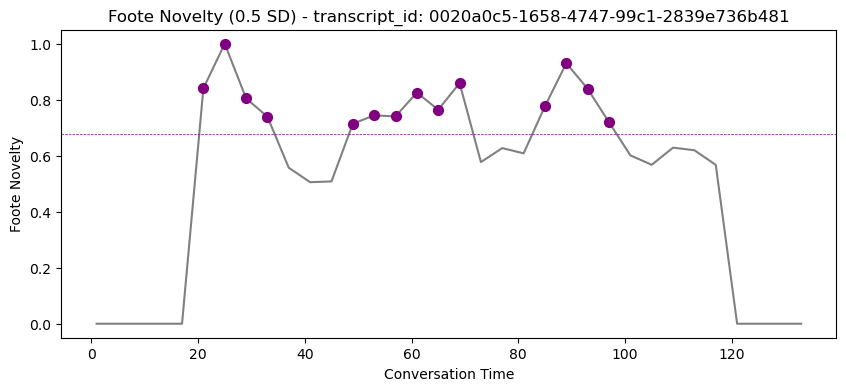

                           transcript_id  time_index  A_start_turn  \
5   0020a0c5-1658-4747-99c1-2839e736b481           5            21   
6   0020a0c5-1658-4747-99c1-2839e736b481           6            25   
7   0020a0c5-1658-4747-99c1-2839e736b481           7            29   
8   0020a0c5-1658-4747-99c1-2839e736b481           8            33   
12  0020a0c5-1658-4747-99c1-2839e736b481          12            49   
13  0020a0c5-1658-4747-99c1-2839e736b481          13            53   
14  0020a0c5-1658-4747-99c1-2839e736b481          14            57   
15  0020a0c5-1658-4747-99c1-2839e736b481          15            61   
16  0020a0c5-1658-4747-99c1-2839e736b481          16            65   
17  0020a0c5-1658-4747-99c1-2839e736b481          17            69   
21  0020a0c5-1658-4747-99c1-2839e736b481          21            85   
22  0020a0c5-1658-4747-99c1-2839e736b481          22            89   
23  0020a0c5-1658-4747-99c1-2839e736b481          23            93   
24  0020a0c5-1658-47

In [38]:
# subset to one type of data
this_data = foote_results["full_sample_tile_4_turn_split_utterances_by_speaker"]
subset = this_data[this_data['transcript_id'] == transcript_id].reset_index(drop=True)
predicted_shift_points = subset[subset['predicted_shift'] == 1]

threshold_val = subset['threshold'].iloc[0]   # get threshold value for this transcript
print(threshold_val) # print threshold

plt.figure(figsize=(10, 4))
sns.lineplot(data=subset, x='A_start_turn', y='foote_novelty', color = 'grey')
plt.scatter(predicted_shift_points['A_start_turn'], predicted_shift_points['foote_novelty'], color = 'purple', s = 50, zorder = 3)
plt.axhline(y=threshold_val, linestyle='--', linewidth=0.5, color='purple')
plt.title(f'Foote Novelty (0.5 SD) - transcript_id: {transcript_id}')
plt.xlabel('Conversation Time')
plt.ylabel('Foote Novelty')
plt.show()

## print predicted shifts
print(subset[subset['predicted_shift'] == 1])

## Distributions

### Overall, split on utterances

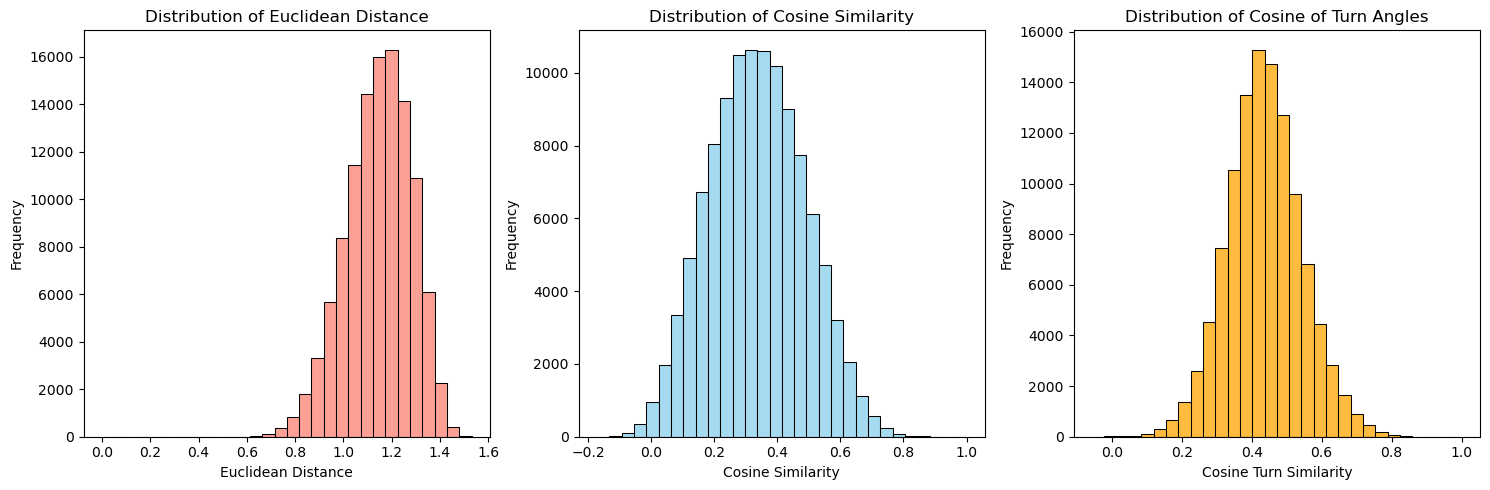

In [40]:
this_data = df = pd.read_pickle(output_dir + '/full_sample_tile_4_turn_split_utterances.pkl')
this_turn_data = turn_angle_results['full_sample_tile_4_turn_split_utterances']

# plot distributions of cosine similarity and euclidean distances and cosine of turn angles
# create figure / axes
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

# plot A - step length (euclidean distance)
sns.histplot(this_data['euclidean_distance'], bins=30, kde=False, ax=axes[0], color='salmon')
axes[0].set_title('Distribution of Euclidean Distance')
axes[0].set_xlabel('Euclidean Distance')
axes[0].set_ylabel('Frequency')

# plot B - cosine similarity
sns.histplot(this_data['cosine_similarity'], bins=30, kde=False, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Cosine Similarity')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Frequency')

# plot C - turn angles
sns.histplot(this_turn_data['cosine_turn'], bins=30, kde=False, ax=axes[2], color="orange")
axes[2].set_title('Distribution of Cosine of Turn Angles')
axes[2].set_xlabel('Cosine Turn Similarity')
axes[2].set_ylabel('Frequency')

# plot
plt.tight_layout()
plt.show()

### Overall, split on sentences

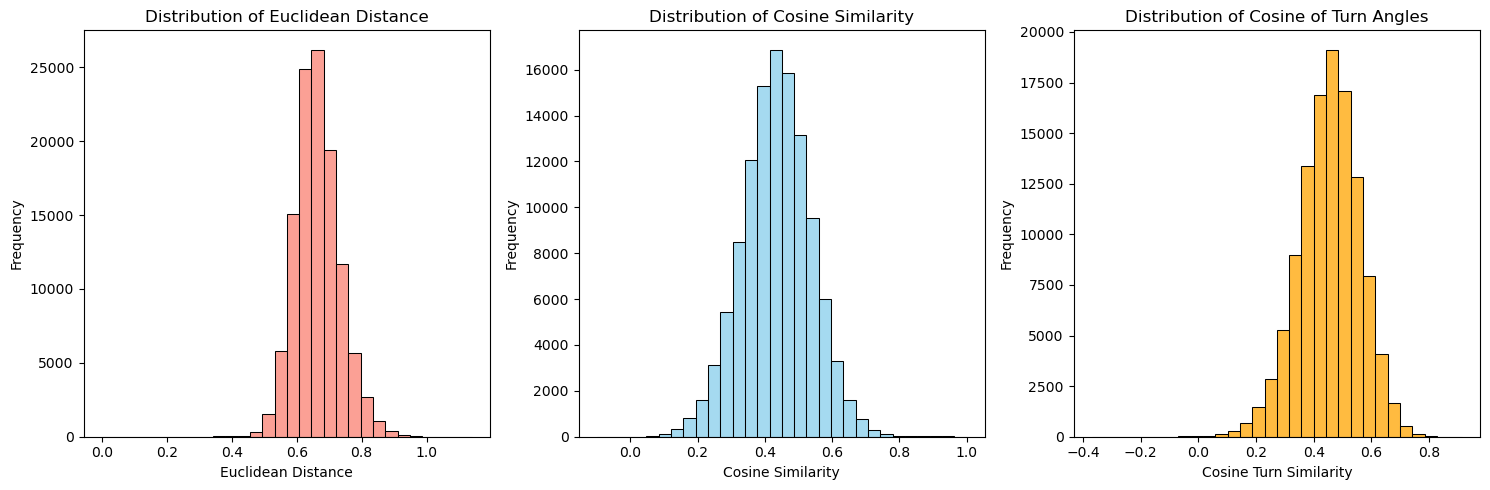

In [41]:
this_data = df = pd.read_pickle(output_dir + '/full_sample_tile_4_turn_split_sentences.pkl')
this_turn_data = turn_angle_results['full_sample_tile_4_turn_split_sentences']

# plot distributions of cosine similarity and euclidean distances and cosine of turn angles
# create figure / axes
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

# plot A - step length (euclidean distance)
sns.histplot(this_data['euclidean_distance'], bins=30, kde=False, ax=axes[0], color='salmon')
axes[0].set_title('Distribution of Euclidean Distance')
axes[0].set_xlabel('Euclidean Distance')
axes[0].set_ylabel('Frequency')

# plot B - cosine similarity
sns.histplot(this_data['cosine_similarity'], bins=30, kde=False, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Cosine Similarity')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Frequency')

# plot C - turn angles
sns.histplot(this_turn_data['cosine_turn'], bins=30, kde=False, ax=axes[2], color="orange")
axes[2].set_title('Distribution of Cosine of Turn Angles')
axes[2].set_xlabel('Cosine Turn Similarity')
axes[2].set_ylabel('Frequency')

# plot
plt.tight_layout()
plt.show()

### Speaker, split by utterances

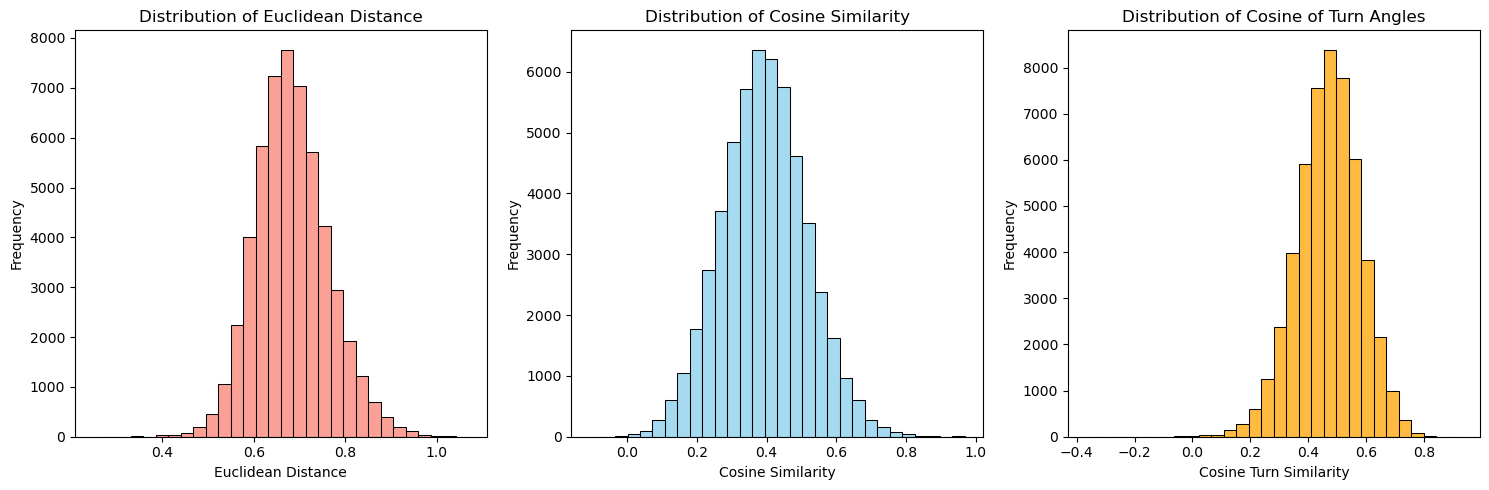

In [42]:
this_data = df = pd.read_pickle(output_dir + '/full_sample_tile_4_turn_split_utterances_by_speaker.pkl')
this_data = this_data.drop_duplicates(subset=['transcript_id', 'A_start_turn'], keep='first')
this_turn_data = turn_angle_results['full_sample_tile_4_turn_split_utterances_by_speaker']

# plot distributions of cosine similarity and euclidean distances and cosine of turn angles
# create figure / axes
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

# plot A - step length (euclidean distance)
sns.histplot(this_data['euclidean_distance'], bins=30, kde=False, ax=axes[0], color='salmon')
axes[0].set_title('Distribution of Euclidean Distance')
axes[0].set_xlabel('Euclidean Distance')
axes[0].set_ylabel('Frequency')

# plot B - cosine similarity
sns.histplot(this_data['cosine_similarity'], bins=30, kde=False, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Cosine Similarity')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Frequency')

# plot C - turn angles
sns.histplot(this_turn_data['cosine_turn'], bins=30, kde=False, ax=axes[2], color="orange")
axes[2].set_title('Distribution of Cosine of Turn Angles')
axes[2].set_xlabel('Cosine Turn Similarity')
axes[2].set_ylabel('Frequency')

# plot
plt.tight_layout()
plt.show()

### Speaker, split by sentences

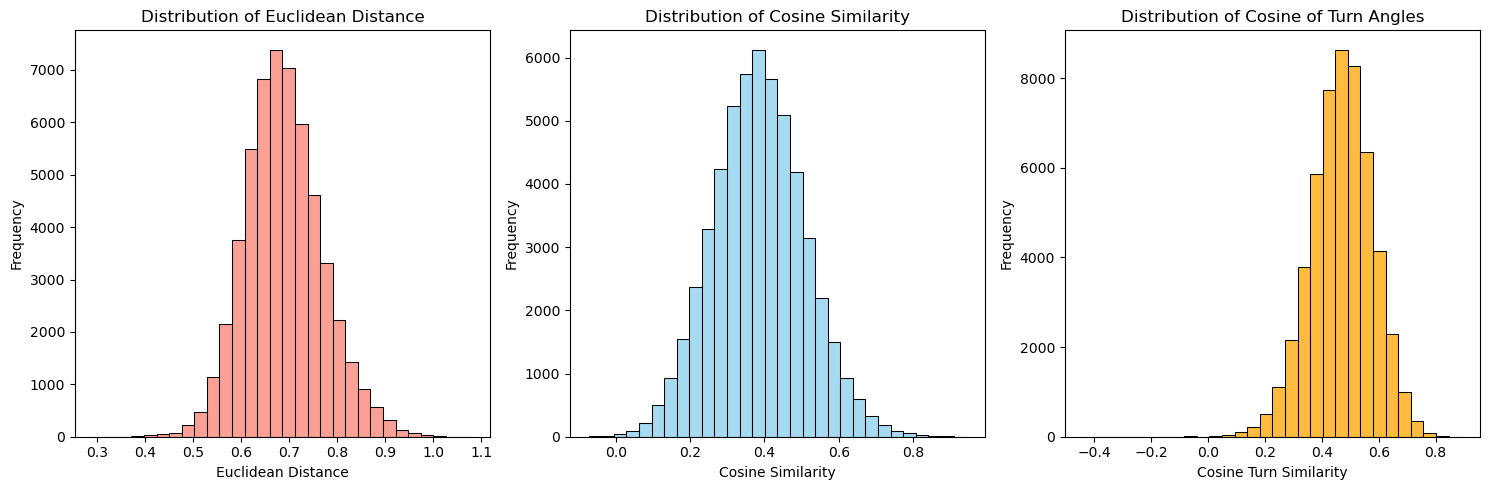

In [43]:
this_data = df = pd.read_pickle(output_dir + '/full_sample_tile_4_turn_split_sentences_by_speaker.pkl')
this_data = this_data.drop_duplicates(subset=['transcript_id', 'A_start_turn'], keep='first')
this_turn_data = turn_angle_results['full_sample_tile_4_turn_split_sentences_by_speaker']

# plot distributions of cosine similarity and euclidean distances and cosine of turn angles
# create figure / axes
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

# plot A - step length (euclidean distance)
sns.histplot(this_data['euclidean_distance'], bins=30, kde=False, ax=axes[0], color='salmon')
axes[0].set_title('Distribution of Euclidean Distance')
axes[0].set_xlabel('Euclidean Distance')
axes[0].set_ylabel('Frequency')

# plot B - cosine similarity
sns.histplot(this_data['cosine_similarity'], bins=30, kde=False, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Cosine Similarity')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Frequency')

# plot C - turn angles
sns.histplot(this_turn_data['cosine_turn'], bins=30, kde=False, ax=axes[2], color="orange")
axes[2].set_title('Distribution of Cosine of Turn Angles')
axes[2].set_xlabel('Cosine Turn Similarity')
axes[2].set_ylabel('Frequency')

# plot
plt.tight_layout()
plt.show()

## Conversation Heatmaps

In [41]:
# define data to create heatmaps (main = overall split long utterances maintaining sentences)
heatmap_data = df = pd.read_pickle(output_dir + '/full_sample_tile_4_turn_split_utterances.pkl')
turn_angle = turn_angle_results['full_sample_tile_4_turn_split_utterances']

# create a test subset before plotting
test_heatmap = heatmap_data[heatmap_data["transcript_id"] == heatmap_data["transcript_id"].iloc[0]].copy()
# define folder output
heatmap_output = '/Users/helenschmidt/Library/CloudStorage/GoogleDrive-helenschmidt129@gmail.com/My Drive/SANLab/Experiments/Conversation-Structure/Candor/analysis-full/output'

# create a folder in the full sample data output to save heatmaps
euclidean_dir = os.path.join(heatmap_output, "euclidean-distance-heatmaps")
os.makedirs(euclidean_dir, exist_ok=True)

cosine_dir = os.path.join(heatmap_output, "cosine-similarity-heatmaps")
os.makedirs(cosine_dir, exist_ok=True)

turn_dir = os.path.join(heatmap_output, "cosine-turn-heatmaps")
os.makedirs(turn_dir, exist_ok=True)

# preview test subset
test_heatmap.head()

,transcript_id,mode,window_size,gap_size,A_start_turn,A_end_turn,B_start_turn,B_end_turn,A_raw_start,A_raw_end,B_raw_start,B_raw_end,A_utterances,B_utterances,A_embeddings,B_embeddings,cosine_similarity,euclidean_distance
0,0020a0c5-1658-4747-99c1-2839e736b481,turn,4,0,1,4,5,8,200.74,214.56,214.03,230.46,"hey I'm gone. good, how are you? Yeah. Yeah, s...",too bad. Is this your first time doing? this i...,"[[0.04145282, -0.00791257, 0.104940765, 0.1183...","[[0.03092037, -0.10058955, 0.0143238, -0.01912...",0.440620,1.057715
1,0020a0c5-1658-4747-99c1-2839e736b481,turn,4,0,5,8,9,12,214.03,230.46,231.64,244.66,too bad. Is this your first time doing? this i...,not too bad. Feel a little crappy today but hu...,"[[0.03092037, -0.10058955, 0.0143238, -0.01912...","[[0.0076957764, -0.0027738144, 0.038302507, -0...",0.276866,1.202609
2,0020a0c5-1658-4747-99c1-2839e736b481,turn,4,0,9,12,13,16,231.64,244.66,244.07,276.46,not too bad. Feel a little crappy today but hu...,the kid hasn't been feeling good and I think s...,"[[0.0076957764, -0.0027738144, 0.038302507, -0...","[[-0.042489365, 0.021653492, 0.09216961, -0.04...",0.522794,0.976940
3,0020a0c5-1658-4747-99c1-2839e736b481,turn,4,0,13,16,17,20,244.07,276.46,277.02,317.65,the kid hasn't been feeling good and I think s...,22 girls if I'm that's awesome. So I have no k...,"[[-0.042489365, 0.021653492, 0.09216961, -0.04...","[[0.037868235, -0.0063665304, 0.023072034, 0.0...",0.177692,1.282426
4,0020a0c5-1658-4747-99c1-2839e736b481,turn,4,0,17,20,21,24,277.02,317.65,317.59,333.26,22 girls if I'm that's awesome. So I have no k...,they've both been pretty good as far as stayin...,"[[0.037868235, -0.0063665304, 0.023072034, 0.0...","[[-0.019834107, -0.07536617, -0.018573657, 0.0...",0.332540,1.155388


In [42]:
# create test subset of turn angle
test_angle = turn_angle[turn_angle["transcript_id"] == heatmap_data["transcript_id"].iloc[0]].copy()

# preview turn angle data
test_angle.head()

,transcript_id,turn_index,A_start_turn,cosine_turn,turn_embedding,BA_vector,BC_vector
0,0020a0c5-1658-4747-99c1-2839e736b481,0,1,0.483136,"[0.03092037, -0.10058955, 0.0143238, -0.019124...","[0.010532452, 0.09267698, 0.090616964, 0.13746...","[-0.023224592, 0.09781574, 0.023978706, 0.0054..."
1,0020a0c5-1658-4747-99c1-2839e736b481,1,5,0.285165,"[0.0076957764, -0.0027738144, 0.038302507, -0....","[0.023224592, -0.09781574, -0.023978706, -0.00...","[-0.05018514, 0.024427306, 0.053867105, -0.031..."
2,0020a0c5-1658-4747-99c1-2839e736b481,2,9,0.356147,"[-0.042489365, 0.021653492, 0.09216961, -0.045...","[0.05018514, -0.024427306, -0.053867105, 0.031...","[0.0803576, -0.028020022, -0.06909758, 0.13506..."
3,0020a0c5-1658-4747-99c1-2839e736b481,3,13,0.442315,"[0.037868235, -0.0063665304, 0.023072034, 0.08...","[-0.0803576, 0.028020022, 0.06909758, -0.13506...","[-0.05770234, -0.06899964, -0.04164569, -0.026..."
4,0020a0c5-1658-4747-99c1-2839e736b481,4,17,0.593736,"[-0.019834107, -0.07536617, -0.018573657, 0.06...","[0.05770234, 0.06899964, 0.04164569, 0.0263642...","[0.008742841, -0.03520325, 0.053654138, -0.017..."


### Euclidean Distance

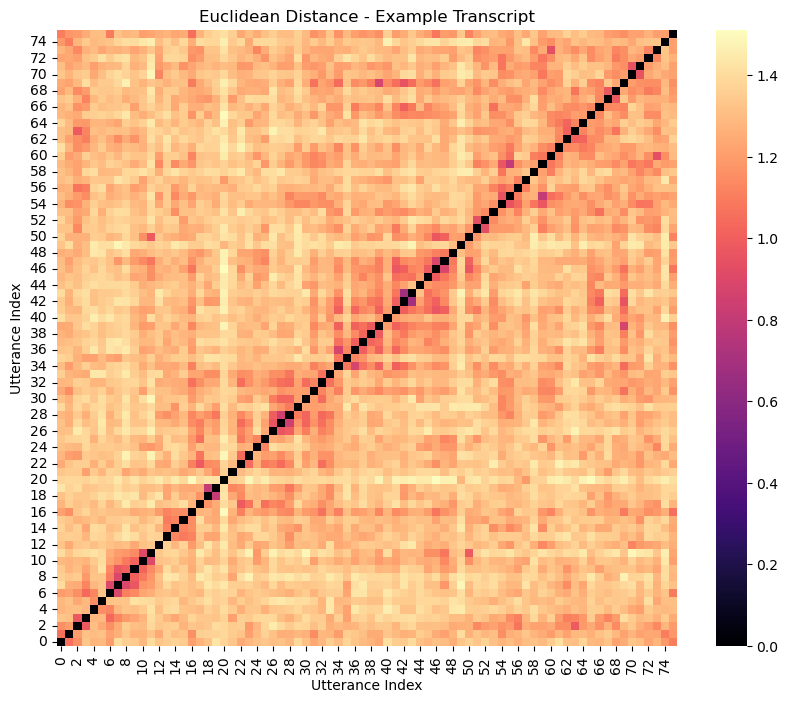

In [36]:
# test euclidean heatmap
embeddings_matrix = np.vstack(test_heatmap['A_embeddings'].values) # get embeddings
distance_matrix = cdist(embeddings_matrix, embeddings_matrix, metric = "euclidean")

# plot
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix, annot=False, cmap='magma')
plt.title(f'Euclidean Distance - Example Transcript')
plt.gca().invert_yaxis()
plt.xlabel('Utterance Index')
plt.ylabel('Utterance Index')
plt.show()

In [7]:
# --- EUCLIDEAN DISTANCE PLOTS --- #
# loop through each unique transcript_id
for transcript_id in heatmap_data['transcript_id'].unique():
    subset = heatmap_data[heatmap_data['transcript_id'] == transcript_id].reset_index(drop=True)
    # add in skip if not enough data exists to compute distances
    if subset.empty or subset.shape[0] < 2:
        continue
    try:
        # stack embeddings into a matrix
        embedding_matrix = np.vstack(subset['A_embeddings'].values)
        # compute pairwise euclidean distance
        distance_matrix = cdist(embedding_matrix, embedding_matrix, metric = "euclidean")
        # plot heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(distance_matrix, annot=False, cmap='magma')
        plt.title(f'Euclidean Distance - transcript_id: {transcript_id}')
        plt.gca().invert_yaxis()
        plt.xlabel('Utterance Index')
        plt.ylabel('Utterance Index')
        # save each plot
        save_id = transcript_id.replace('/', '_')  # edit ID in case there are problematic characters
        plot_path = os.path.join(euclidean_dir, f"{save_id}.png")
        plt.savefig(plot_path, bbox_inches='tight')
        plt.close()

    except Exception as e:
        print(f"Error creating heatmap for {transcript_id}: {e}")

### Cosine Similarity

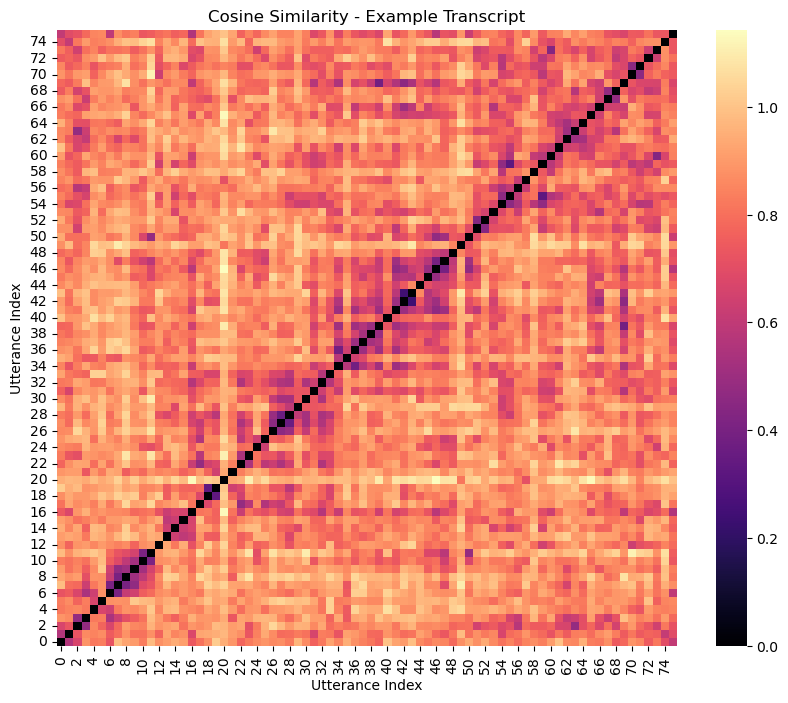

In [50]:
# test cosine heatmap
embeddings_matrix = np.vstack(test_heatmap['A_embeddings'].values) # get embeddings
distance_matrix = cdist(embeddings_matrix, embeddings_matrix, metric = "cosine")

# plot
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix, annot=False, cmap='magma')
plt.title(f'Cosine Similarity - Example Transcript')
plt.gca().invert_yaxis()
plt.xlabel('Utterance Index')
plt.ylabel('Utterance Index')
plt.show()

In [ ]:
# --- COSINE SIMILARITY PLOTS --- #
# loop through each unique transcript_id
for transcript_id in heatmap_data['transcript_id'].unique():
    subset = heatmap_data[heatmap_data['transcript_id'] == transcript_id].reset_index(drop=True)
    # add in skip if not enough data exists to compute distances
    if subset.empty or subset.shape[0] < 2:
        continue
    try:
        # stack embeddings into a matrix
        embedding_matrix = np.vstack(subset['A_embeddings'].values)
        # compute pairwise euclidean distance
        distance_matrix = cdist(embedding_matrix, embedding_matrix, metric = "cosine")
        # plot heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(distance_matrix, annot=False, cmap='magma')
        plt.title(f'Cosine Similarity - transcript_id: {transcript_id}')
        plt.gca().invert_yaxis()
        plt.xlabel('Utterance Index')
        plt.ylabel('Utterance Index')
        # save each plot
        save_id = transcript_id.replace('/', '_')  # edit ID in case there are problematic characters
        plot_path = os.path.join(cosine_dir, f"{save_id}.png")
        plt.savefig(plot_path, bbox_inches='tight')
        plt.close()

    except Exception as e:
        print(f"Error creating heatmap for {transcript_id}: {e}")

### Cosine of Turn Angle

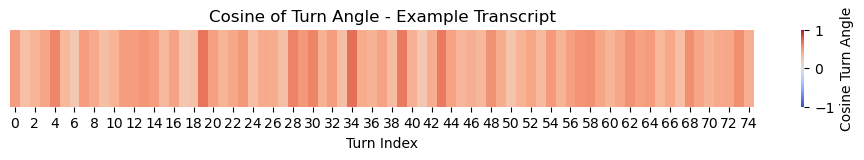

In [ ]:
# stack BA and BC vectors 
BA_matrix = np.vstack(test_angle['BA_vector'].values)
BC_matrix = np.vstack(test_angle['BC_vector'].values)

# cosine turn per row
cos_turn = test_angle['cosine_turn'].values

# plot as 1D heatmap
plt.figure(figsize=(12,1))
sns.heatmap(cos_turn.reshape(1,-1), cmap='coolwarm', vmin=-1, vmax=1,
            cbar_kws={'label':'Cosine Turn Angle'})
plt.xlabel('Utterance Index')
plt.yticks([])
plt.title(f'Cosine of Turn Angle - Example Transcript')
plt.show()


In [53]:
# --- COSINE TURN ANGLE PLOTS --- #
# loop through each unique transcript_id
for transcript_id in turn_angle['transcript_id'].unique():
    subset = turn_angle[turn_angle['transcript_id'] == transcript_id].reset_index(drop=True)
    # add in skip if not enough data exists to compute distances
    if subset.empty or subset.shape[0] < 2:
        continue
    try:
        # stack BA and BC vectors 
        BA_matrix = np.vstack(subset['BA_vector'].values)
        BC_matrix = np.vstack(subset['BC_vector'].values)

        # cosine turn per row
        cos_turn = subset['cosine_turn'].values
        
        # plot as 1D heatmap
        plt.figure(figsize=(12,1))
        sns.heatmap(cos_turn.reshape(1,-1), cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={'label':'Cosine Turn Angle'})
        plt.xlabel('Utterance Index')
        plt.yticks([])
        plt.title(f'Cosine of Turn Angle - transcript_id: {transcript_id}')

        # save each plot
        save_id = transcript_id.replace('/', '_')  # edit ID in case there are problematic characters
        plot_path = os.path.join(turn_dir, f"{save_id}.png")
        plt.savefig(plot_path, bbox_inches='tight')
        plt.close()

    except Exception as e:
        print(f"Error creating heatmap for {transcript_id}: {e}")

### Foote Novelty

In [55]:
# get foote novelty results to create heatmap
foote = foote_results["full_sample_tile_4_turn_split_sentences"]

# create test subset
test_foote = foote[foote["transcript_id"] == foote["transcript_id"].iloc[0]].copy()

# create folder to save heatmaps
foote_dir = os.path.join(heatmap_output, "foote-novelty-heatmaps")
os.makedirs(foote_dir, exist_ok=True)

# preview test subset
test_foote.head()

,transcript_id,time_index,A_start_turn,foote_novelty,speaker,predicted_shift,threshold
0,0020a0c5-1658-4747-99c1-2839e736b481,0,1,0.0,None,0,0.667243
1,0020a0c5-1658-4747-99c1-2839e736b481,1,5,0.0,None,0,0.667243
2,0020a0c5-1658-4747-99c1-2839e736b481,2,9,0.0,None,0,0.667243
3,0020a0c5-1658-4747-99c1-2839e736b481,3,13,0.0,None,0,0.667243
4,0020a0c5-1658-4747-99c1-2839e736b481,4,17,0.0,None,0,0.667243


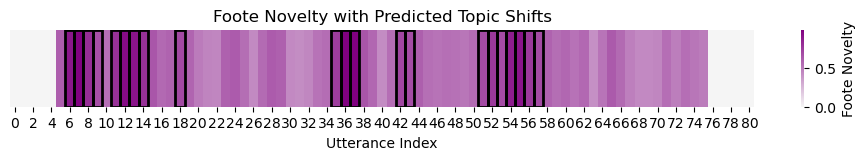

In [77]:
# continuous values for gradient
values = test_foote['foote_novelty'].values
# binary shift mask
shift = test_foote['predicted_shift'].values.astype(bool)
# create custom grey-purple colormap
cmap = LinearSegmentedColormap.from_list("grey_purple", ["#f5f5f5", "purple"])

plt.figure(figsize=(12, 1))

# plot heatmap of the continuous gradient
ax = sns.heatmap(
    values.reshape(1, -1),
    cmap=cmap,
    cbar=True,
    linewidths=0,
    linecolor='black',
    yticklabels=False,
    cbar_kws={'label':'Foote Novelty'}
)

# overlay black borders for predicted shifts
for i, is_shift in enumerate(shift):
    if is_shift:
        # Rectangle around the cell
        ax.add_patch(
            plt.Rectangle(
                (i, 0), 1, 1, fill=False, edgecolor='black', lw=2
            )
        )

plt.title("Foote Novelty with Predicted Topic Shifts")
plt.xlabel('Utterance Index')
plt.gca().invert_yaxis()
plt.show()

In [78]:
# create custom grey-purple colormap
cmap = LinearSegmentedColormap.from_list("grey_purple", ["#f5f5f5", "purple"])

# --- FOOTE NOVELTY PLOTS --- #
# loop through each unique transcript_id
for transcript_id in foote['transcript_id'].unique():
    subset = foote[foote['transcript_id'] == transcript_id].reset_index(drop=True)
    # add in skip if not enough data exists to compute distances
    if subset.empty or subset.shape[0] < 2:
        continue
    try:
        # get continuous values for gradient
        values = subset['foote_novelty'].values
        # binary shift mask
        shift = subset['predicted_shift'].values.astype(bool)
        
        plt.figure(figsize=(12, 1))
        # plot heatmap of the continuous gradient
        ax = sns.heatmap(
            values.reshape(1, -1),
            cmap=cmap,
            cbar=True,
            linewidths=0,
            linecolor='black',
            yticklabels=False,
            cbar_kws={'label':'Foote Novelty'}
        )

        plt.xlabel('Utterance Index')
        plt.yticks([])
        plt.title(f'Foote Novelty - transcript_id: {transcript_id}')
        plt.gca().invert_yaxis()

        # overlay black borders for predicted shifts
        for i, is_shift in enumerate(shift):
            if is_shift:
                # Rectangle around the cell
                ax.add_patch(
                    plt.Rectangle(
                        (i, 0), 1, 1, fill=False, edgecolor='black', lw=2
                    )
                )

        # save each plot
        save_id = transcript_id.replace('/', '_')  # edit ID in case there are problematic characters
        plot_path = os.path.join(foote_dir, f"{save_id}.png")
        plt.savefig(plot_path, bbox_inches='tight')
        plt.close()

    except Exception as e:
        print(f"Error creating heatmap for {transcript_id}: {e}")